Ava voy a recrear la síntesis FM para imitar un wav

In [204]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
import scipy.io.wavfile as wav
from scipy.fftpack import fft
import sounddevice as sd

In [248]:
fs, data = wav.read("GRWL ROAR ANGRY.wav")

print("Sample rate:", fs)
print("Data shape:", data.shape)
print("duracion:", data.shape[0] / fs, "s")

Sample rate: 44100
Data shape: (158524,)
duracion: 3.5946485260770977 s


A 44100 muestras por segundo y N = 158524 muestras, para 100 ms son 4410 muestras

In [ ]:
data = data

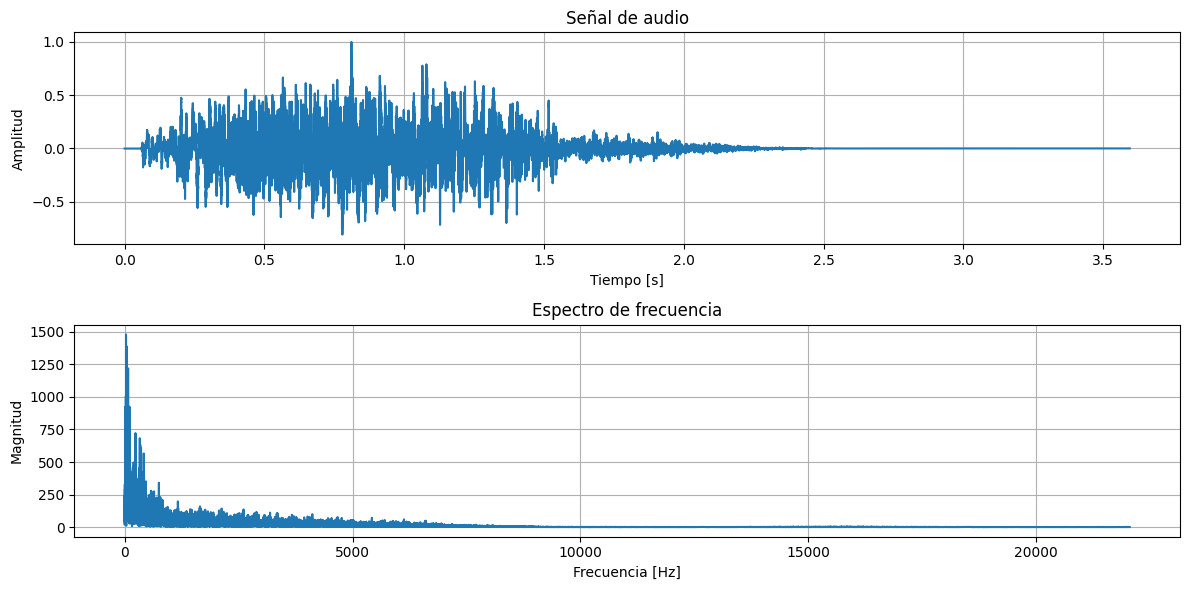

In [260]:

if data.ndim > 1:
    data = data[:, 0]  # solo un canal si estéreo

data = data.astype(float) / np.max(np.abs(data))
t = np.linspace(0, len(data)/fs, len(data), endpoint=False)

espectro= fft(data)

frecuencias = np.fft.fftfreq(len(data), 1/fs)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, data, label='Señal de audio')
plt.title('Señal de audio')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(frecuencias[:len(frecuencias)//2], np.abs(espectro)[:len(espectro)//2], label='Espectro de frecuencia')
plt.title('Espectro de frecuencia')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud')
plt.grid()
plt.tight_layout()
plt.show()

In [261]:
peaks, _ = scipy.signal.find_peaks(np.abs(espectro), distance= 1000, prominence=0.1)

peak_frequencies = frecuencias[peaks]
peak_frequencies = peak_frequencies[0:15]

print("Frecuencias de los picos:", peak_frequencies)

Frecuencias de los picos: [  29.76647069  332.16042997  751.11655018 1167.84713987 1652.7346017
 2127.05079357 2608.043577   2891.52052686 3190.01980773 3668.78706063
 4116.95326891 4670.55398552 4969.88784033 5423.33968358 5704.86929424]


In [262]:
f_m = 200

# Parámetros de portadoras
fc_list = [  29.7,  100, 332.1, 751.1, 1167.8, 1652.7, 2127, 2608, 2891.5, 3190, 3668.7, 4116.9, 4670.5, 4969.8, 5423.3, 5704.8]
I_list = [1, 5, 5, 5, 10, 1, 6, 5, 1, 7, 1, 1, 5, 10, 8, 10]
A_list = [1.1, 1, 0.5, 0.5, 0.3, 0.3, 0.1, 0.1, 0.08, 0.07, 0.08, 0.06, 0.05, 0.05, 0.03, 0.01]

# Generar señal
signal = np.zeros_like(t)
for fc, I, A in zip(fc_list, I_list, A_list):
    signal += A * np.sin(2 * np.pi * fc * t + I * np.sin(2 * np.pi * f_m * t))

# Normalizar y reproducir
signal /= np.max(np.abs(signal))
#sd.play(signal, fs)
#sd.wait()
espectro_fm = fft(signal)
frecuencias_fm = np.fft.fftfreq(len(signal), 1/fs)

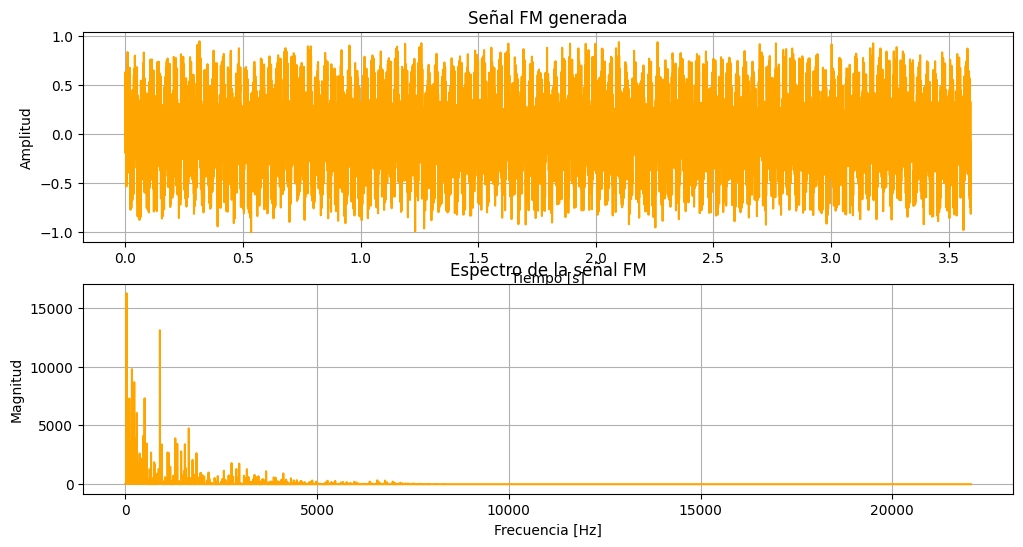

In [263]:

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal, color='orange')
plt.title("Señal FM generada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(frecuencias_fm[:len(frecuencias_fm)//2], np.abs(espectro_fm)[:len(espectro_fm)//2], color='orange')
plt.title("Espectro de la señal FM")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.grid()


Ahora un ADSR para moldear un poco (gracias CHAT GPT)

In [264]:
def apply_adsr(signal, fs, adsr, sustain_level=0.7):
    """
    Aplica una envolvente ADSR lineal a una señal dada.
    
    Parámetros:
        signal (np.ndarray): señal de entrada.
        fs (int): frecuencia de muestreo.
        adsr (tuple): (A, D, S, R) en segundos.
        sustain_level (float): valor entre 0 y 1 para el nivel de sustain.
    
    Retorna:
        señal con ADSR aplicada (np.ndarray)
    """
    A, D, S, R = adsr
    N = len(signal)
    t_total = N / fs
    t = np.linspace(0, t_total, N, endpoint=False)

    len_A = int(A * fs)
    len_D = int(D * fs)
    len_S = int(S * fs)
    len_R = int(R * fs)

    total_env_len = len_A + len_D + len_S + len_R

    if total_env_len > N:
        raise ValueError("ADSR más larga que la señal. Reduce alguno de sus tiempos.")

    # Construcción de la envolvente lineal
    env = np.zeros(N)
    env[:len_A] = np.linspace(0, 1, len_A)
    env[len_A:len_A + len_D] = np.linspace(1, sustain_level, len_D)
    env[len_A + len_D:len_A + len_D + len_S] = sustain_level
    env[len_A + len_D + len_S:len_A + len_D + len_S + len_R] = np.linspace(sustain_level, 0, len_R)

    # Rellenar lo que queda (si sobra espacio)
    if len_A + len_D + len_S + len_R < N:
        env[len_A + len_D + len_S + len_R:] = 0.0

    # Aplicar la envolvente a la señal
    return signal * env

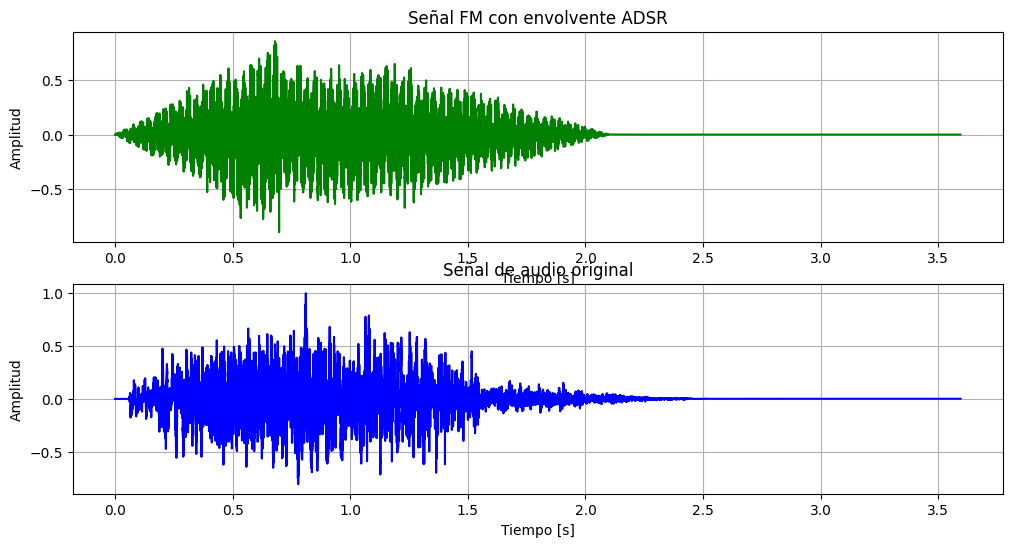

In [265]:
adsr = (0.7, 0, 0.5, 0.9)  # (A, D, S, R) en segundos
signal_adsr = apply_adsr(signal, fs, adsr)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal_adsr, color='green')
plt.title("Señal FM con envolvente ADSR")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(t, data, color='blue')
plt.title("Señal de audio original")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()

In [257]:
sd.play(signal_adsr, fs)
sd.wait()

In [266]:
error_entre_señales = np.mean((signal_adsr - data[:len(signal_adsr)])**2)
print("Error entre señales (MSE):", error_entre_señales)

Error entre señales (MSE): 0.03300783421048935
